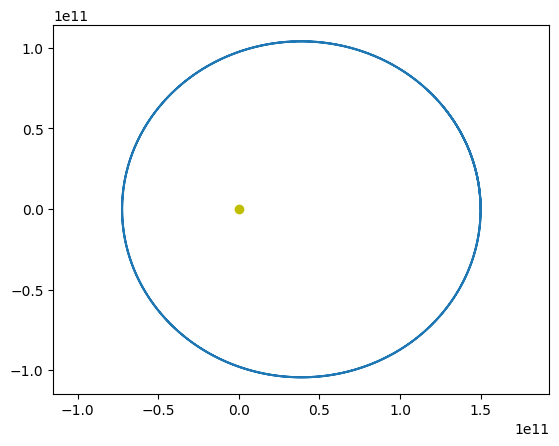

In [2]:
import numpy as np
import matplotlib.pyplot as plt

G = 6.674e-11
M = 1.989e30        # Solens masse [kg]
dt = 60 * 60 * 6    # tidsskridt: 6 timer [s]

def acceleration(x, y):
    """Tyngdeacceleration mod centrallegemet i origo."""
    r = np.hypot(x, y)
    a = -G * M / r**2
    return a * x / r, a * y / r

# Start i aphel med fart under den cirkulære -> ellipse
x, y = 1.5e11, 0.0
vx, vy = 0.0, 24000.0     # m/s

xs, ys = [], []
for _ in range(2000):
    ax, ay = acceleration(x, y)
    vx, vy = vx + ax * dt, vy + ay * dt   # symplektisk Euler -> stabil bane
    x,  y  = x + vx * dt,  y + vy * dt
    xs.append(x); ys.append(y)

plt.plot(xs, ys)
plt.plot(0, 0, 'yo')      # centrallegemet
plt.axis('equal'); plt.show()

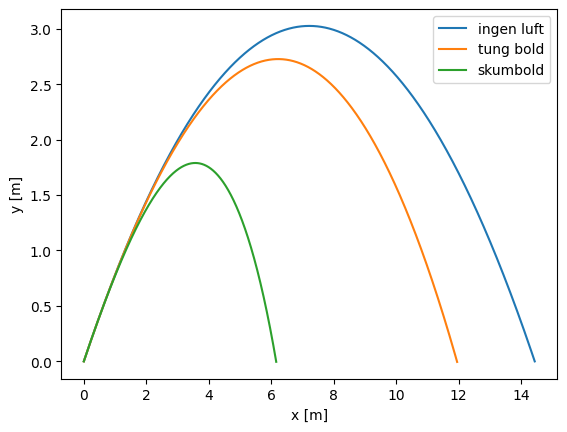

In [2]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.82          # tyngdeacceleration [m/s^2]
dt = 0.001        # tidsskridt [s]

def kast(v0, vinkel_grader, k_over_m):
    """Simulerer et skråt kast med luftmodstand proportional med v^2.
    k_over_m er konstanten (0.5*rho*Cd*A)/m. Sæt 0 for intet luftmodstand."""
    a = np.radians(vinkel_grader)
    vx, vy = v0 * np.cos(a), v0 * np.sin(a)
    x, y = 0.0, 0.0
    xs, ys = [x], [y]
    while y >= 0:
        v = np.hypot(vx, vy)
        ax = -k_over_m * v * vx
        ay = -g - k_over_m * v * vy
        vx, vy = vx + ax * dt, vy + ay * dt
        x, y = x + vx * dt, y + vy * dt
        xs.append(x); ys.append(y)
    return xs, ys

# Sammenlign tung bold (lille k/m) med let skumbold (stor k/m)
for k, navn in [(0.0, "ingen luft"), (0.02, "tung bold"), (0.15, "skumbold")]:
    xs, ys = kast(12, 40, k)
    plt.plot(xs, ys, label=navn)

plt.xlabel("x [m]"); plt.ylabel("y [m]"); plt.legend(); plt.show()

In [3]:
import numpy as np

h = 6.626e-34      # Plancks konstant [J·s]
c = 2.998e8        # lysets fart [m/s]
eV = 1.602e-19     # 1 elektronvolt [J]

def fotonenergi(lambda_m):
    """Fotonens energi (J) ud fra bølgelængden i meter."""
    return h * c / lambda_m

def fotonimpuls(lambda_m):
    """Fotonens bevægelsesmængde (kg·m/s) ud fra bølgelængden i meter."""
    return h / lambda_m

# Balmer-linjer (nm) -> meter
balmer_nm = np.array([656.3, 486.1, 434.0, 410.2])
balmer_m = balmer_nm * 1e-9

for lam_nm, lam_m in zip(balmer_nm, balmer_m):
    E = fotonenergi(lam_m)
    p = fotonimpuls(lam_m)
    print(f"{lam_nm:6.1f} nm:  E = {E/eV:5.3f} eV,  p = {p:.3e} kg*m/s")

 656.3 nm:  E = 1.889 eV,  p = 1.010e-27 kg*m/s
 486.1 nm:  E = 2.551 eV,  p = 1.363e-27 kg*m/s
 434.0 nm:  E = 2.857 eV,  p = 1.527e-27 kg*m/s
 410.2 nm:  E = 3.023 eV,  p = 1.615e-27 kg*m/s
